# Visualize Pythomics feature outputs

Install the notebook's optional plotting and JPEG 2000 preview dependencies with `python -m pip install -e '.[visualization]'`. This notebook extracts features from `LR10_N101_S09_HE_shell.jp2`, saves the feature maps as a MAT file under `outputs/`, and compares the label map and MAT outputs with the matching original histology image, `LR10_N101_S09_HE.jp2`.

The input slide is very large. The original image is decoded at reduced resolution for display; feature extraction still uses the full-resolution label map. Density maps are stored at the configured block resolution, while object feature maps retain the label-map resolution.

In [1]:
from pathlib import Path
import sys

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "src" / "pythomics").is_dir()
)
sys.path.insert(0, str(ROOT / "src"))

LABEL_MAP_PATH = ROOT / "LR10_N101_S09_HE_shell.jp2"
ORIGINAL_IMAGE_PATH = ROOT / "LR10_N101_S09_HE.jp2"
OUTPUT_DIR = ROOT / "outputs"
MAT_PATH = OUTPUT_DIR / f"{LABEL_MAP_PATH.stem}_features.mat"

for path in (LABEL_MAP_PATH, ORIGINAL_IMAGE_PATH):
    if not path.is_file():
        raise FileNotFoundError(f"Expected input image was not found: {path}")

print(f"Label map: {LABEL_MAP_PATH}")
print(f"Original image: {ORIGINAL_IMAGE_PATH}")
print(f"MAT output: {MAT_PATH}")

Label map: /home/coder/pythomics/LR10_N101_S09_HE_shell.jp2
Original image: /home/coder/pythomics/LR10_N101_S09_HE.jp2
MAT output: /home/coder/pythomics/outputs/LR10_N101_S09_HE_shell_features.mat


## Extract and save the MAT feature maps

Run this cell to generate the CSV tables, density arrays, and full-resolution MAT maps from the label JP2. The default Pythomics label values and 20 × 20 density blocks are used.

In [ ]:
import numpy as np
from PIL import Image

from pythomics.core import extract_features, save_outputs

def read_label_map(path):
    max_pixels = Image.MAX_IMAGE_PIXELS
    try:
        Image.MAX_IMAGE_PIXELS = None
        with Image.open(path) as image:
            return np.asarray(image)
    finally:
        Image.MAX_IMAGE_PIXELS = max_pixels


label_map = read_label_map(LABEL_MAP_PATH)
if label_map.ndim != 2 or not np.issubdtype(label_map.dtype, np.integer):
    raise ValueError(f"Expected a 2-D integer label map, got {label_map.shape} ({label_map.dtype})")
print(f"Label map shape: {label_map.shape}, dtype: {label_map.dtype}")

densities, lumen_features, epithelium_features = extract_features(label_map)
save_outputs(
    label_map,
    densities,
    lumen_features,
    epithelium_features,
    OUTPUT_DIR,
    LABEL_MAP_PATH.stem,
    save_mat=True,
    
)

print(f"Saved MAT maps to {MAT_PATH}")
print(f"Lumen objects: {len(lumen_features):,}")
print(f"Epithelium objects: {len(epithelium_features):,}")

## Compare the label map and original slide

OpenJPEG decodes a 1/16-size preview of the original slide directly, so the notebook does not need to hold the full-color slide in memory.

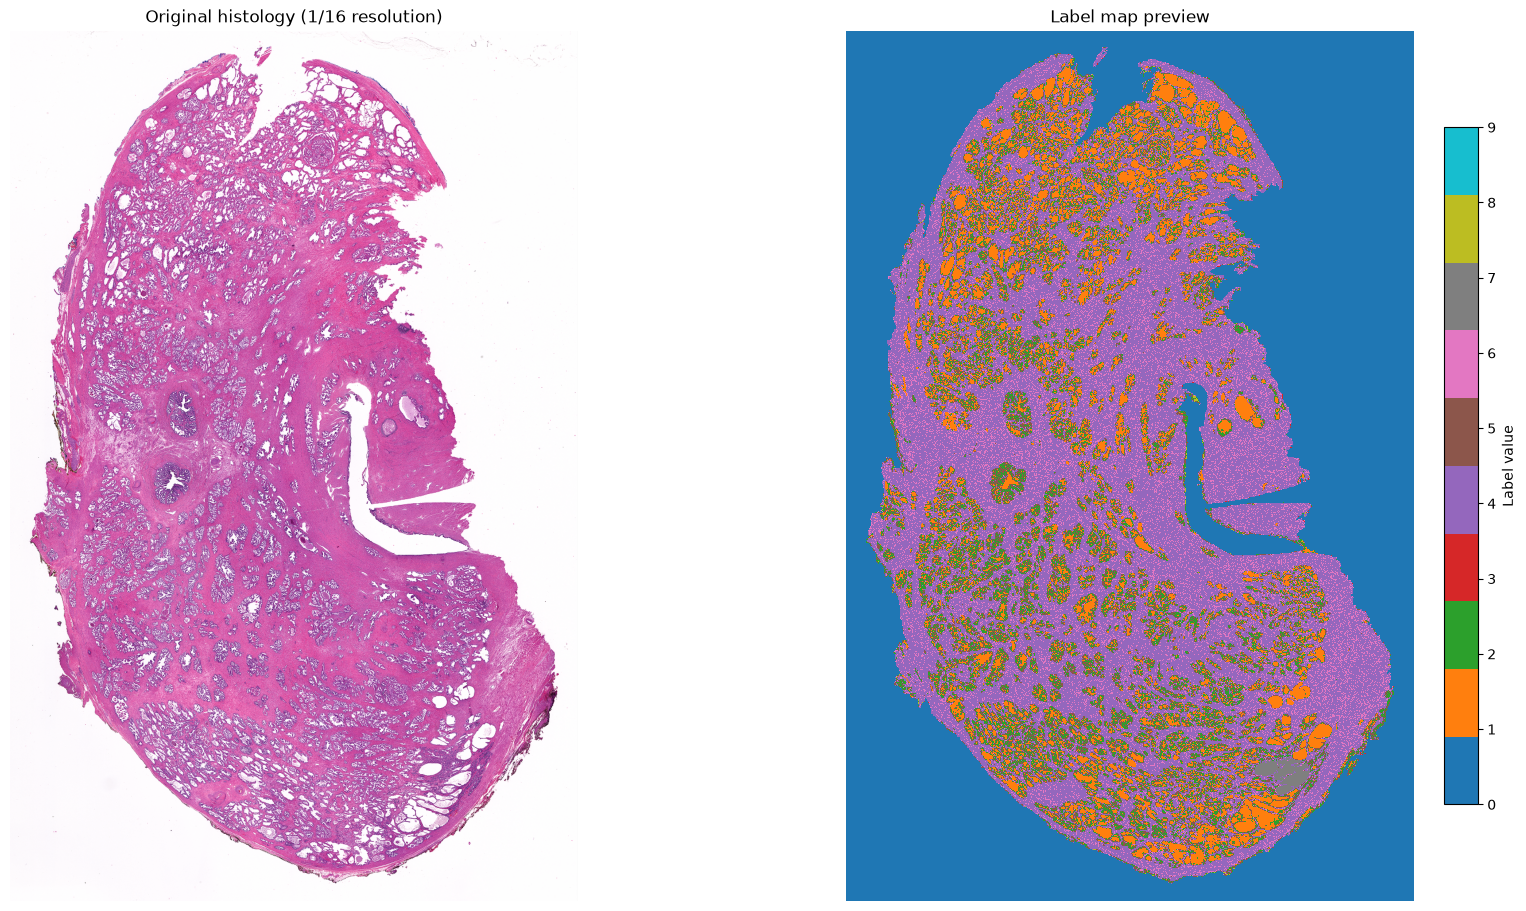

In [10]:
import matplotlib.pyplot as plt

import glymur

preview_step = 16
original_preview = glymur.Jp2k(str(ORIGINAL_IMAGE_PATH))[::preview_step, ::preview_step]

label_preview = label_map[::preview_step, ::preview_step]

fig, axes = plt.subplots(1, 2, figsize=(16, 9), constrained_layout=True)
axes[0].imshow(original_preview)
axes[0].set_title(f"Original histology (1/{2**4} resolution)")
axes[0].axis("off")

label_image = axes[1].imshow(label_preview, cmap="tab10", vmin=0, vmax=9, interpolation="nearest")
axes[1].set_title("Label map preview")
axes[1].axis("off")
fig.colorbar(label_image, ax=axes[1], fraction=0.046, pad=0.04, label="Label value")
plt.show()

## Visualize the saved MAT maps

Density maps are block-summed at 20 × 20 pixels, so their display extent is scaled back to the source-image coordinates. Full-resolution object maps are sampled for display only; the saved MAT data remains full resolution.

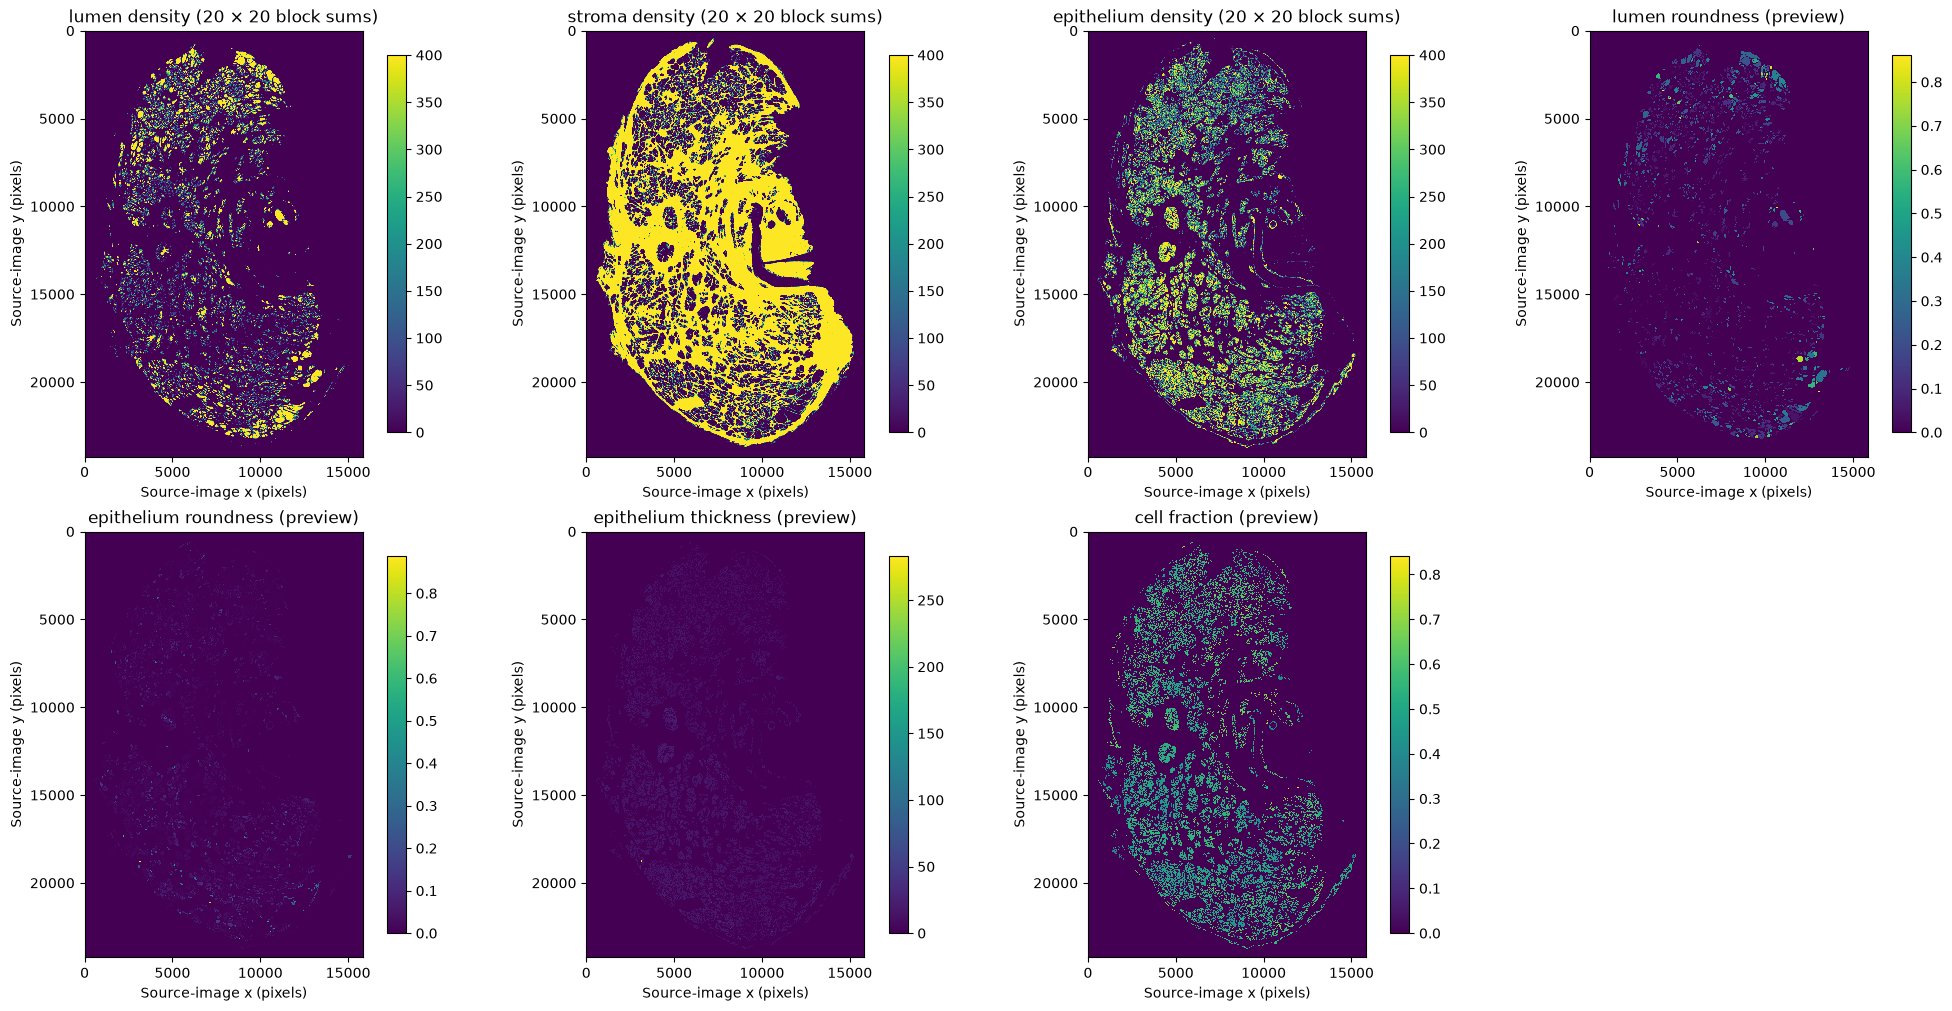

In [11]:
from scipy.io import loadmat

if not MAT_PATH.is_file():
    raise FileNotFoundError(f"Run the extraction cell first; MAT file is missing: {MAT_PATH}")

map_names = (
    "lumen_density",
    "stroma_density",
    "epithelium_density",
    "lumen_roundness",
    "epithelium_roundness",
    "epithelium_thickness",
    "cell_fraction",
)
feature_maps = loadmat(MAT_PATH, variable_names=map_names)

height, width = label_map.shape
fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)

for ax, name in zip(axes.flat, map_names):
    values = feature_maps[name].squeeze()
    if name.endswith("_density"):
        extent = (0, width, height, 0)
        title = name.replace("_", " ") + " (20 × 20 block sums)"
    else:
        values = values[::preview_step, ::preview_step]
        extent = (0, width, height, 0)
        title = name.replace("_", " ") + " (preview)"
    display = ax.imshow(values, cmap="viridis", extent=extent, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Source-image x (pixels)")
    ax.set_ylabel("Source-image y (pixels)")
    fig.colorbar(display, ax=ax, fraction=0.046, pad=0.04)

axes.flat[-1].axis("off")
plt.show()